<a href="https://colab.research.google.com/github/Royc4515/Project1_SignalProcessing/blob/main/Project1_SignalProcessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# Project 1 - Signal Processing
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal

# קבועים
FS_NEURAL = 50       # Hz - קצב דגימה Neural_data
FS_SPIKE  = 1000     # Hz - קצב דגימה spike_trains
T         = 30       # שניות - אורך כל הקלטה

# טעינת נתונים
neural_df = pd.read_csv('Neural_data.csv')
spike_df  = pd.read_csv('spike_trains.csv')

print("Neural data shape:", neural_df.shape)
print("Neural data columns:", neural_df.columns.tolist())
print(neural_df.head())
print()
print("Spike trains shape:", spike_df.shape)
print("First trial_neuron values:", spike_df['trial_neuron'].unique()[:10])

Neural data shape: (1500, 2)
Neural data columns: ['Frame', 'ΔF/F (%)']
   Frame  ΔF/F (%)
0      0  0.074947
1      1  0.007558
2      2 -0.004470
3      3 -0.003576
4      4 -0.026911

Spike trains shape: (500, 30001)
First trial_neuron values: ['1_A' '1_B' '1_C' '1_D' '1_E' '2_A' '2_B' '2_C' '2_D' '2_E']


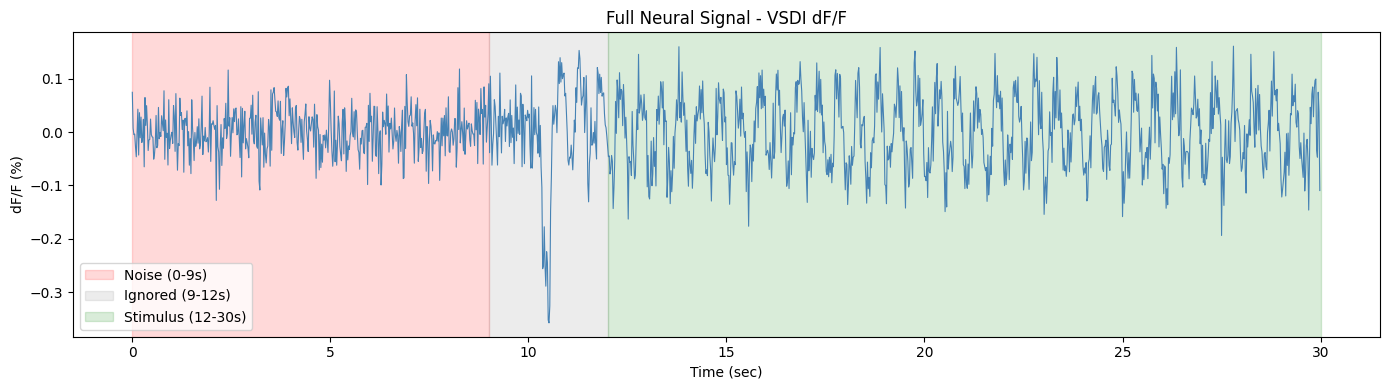

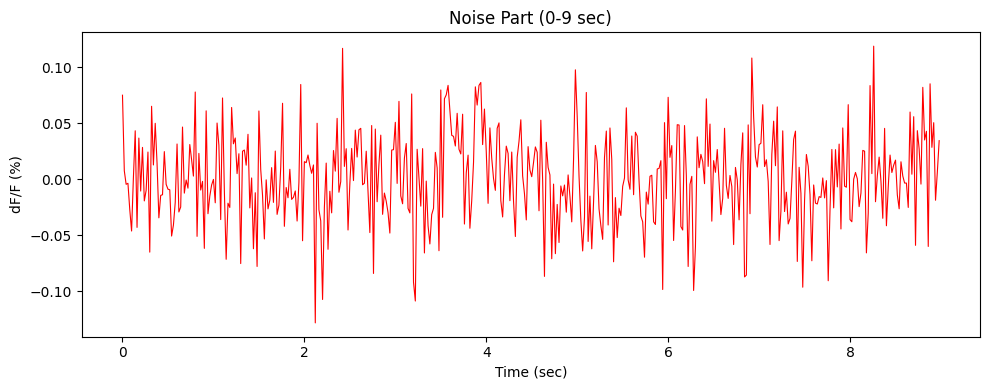

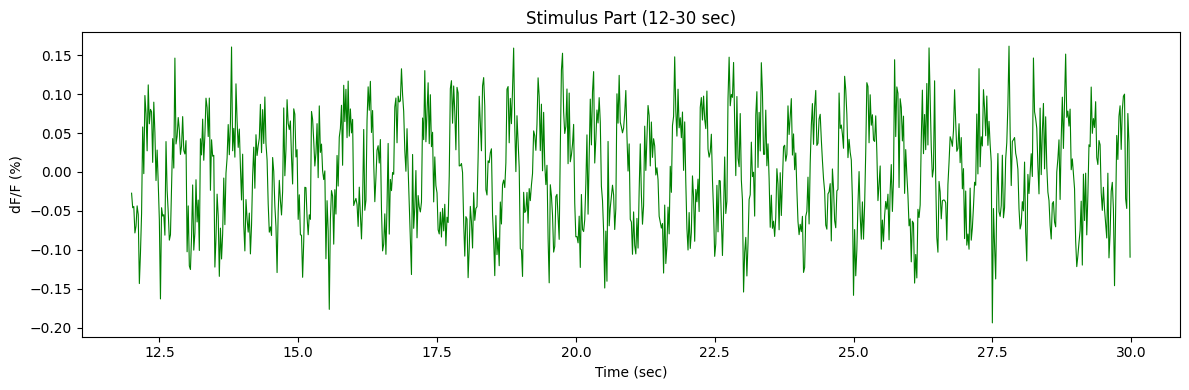

Noise samples: 450
Stimulus samples: 900


In [ ]:
# ============================================================
# Part 1A - Division into signal parts
# ============================================================

dff    = neural_df['ΔF/F (%)'].values
frames = neural_df['Frame'].values
time   = frames / FS_NEURAL

noise_mask    = time < 9
stimulus_mask = time >= 12

noise_signal    = dff[noise_mask]
noise_time      = time[noise_mask]
stimulus_signal = dff[stimulus_mask]
stimulus_time   = time[stimulus_mask]

# Plot 1: Full signal
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(time, dff, color='steelblue', linewidth=0.8)
ax.axvspan(0,  9,  alpha=0.15, color='red',   label='Noise (0-9s)')
ax.axvspan(9,  12, alpha=0.15, color='gray',  label='Ignored (9-12s)')
ax.axvspan(12, 30, alpha=0.15, color='green', label='Stimulus (12-30s)')
ax.set_title('Full Neural Signal - VSDI dF/F')
ax.set_xlabel('Time (sec)')
ax.set_ylabel('dF/F (%)')
ax.legend()
plt.tight_layout()
plt.show()

# Plot 2: Noise part
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(noise_time, noise_signal, color='red', linewidth=0.8)
ax.set_title('Noise Part (0-9 sec)')
ax.set_xlabel('Time (sec)')
ax.set_ylabel('dF/F (%)')
plt.tight_layout()
plt.show()

# Plot 3: Stimulus part
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(stimulus_time, stimulus_signal, color='green', linewidth=0.8)
ax.set_title('Stimulus Part (12-30 sec)')
ax.set_xlabel('Time (sec)')
ax.set_ylabel('dF/F (%)')
plt.tight_layout()
plt.show()

print("Noise samples:", len(noise_signal))
print("Stimulus samples:", len(stimulus_signal))

Decimation factors: [2, 5, 15]


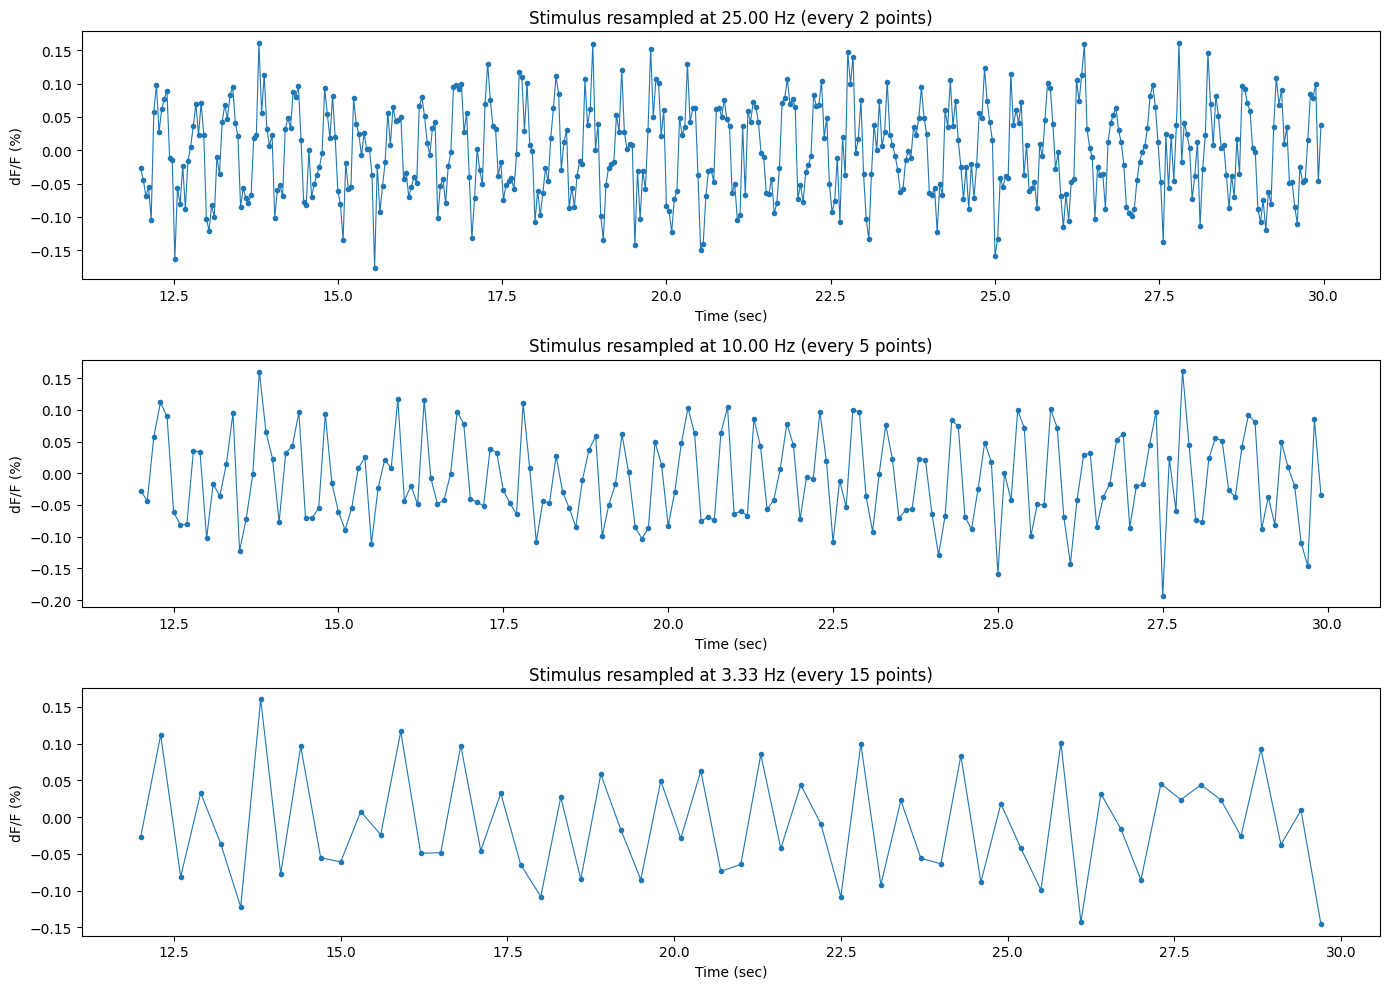

In [ ]:
# ============================================================
# Part 1B - Manual Resampling
# ============================================================

new_rates   = [25, 10, 10/3]
decimations = [2,   5,  15]

print("Decimation factors:", decimations)

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

for i, (fs_new, dec) in enumerate(zip(new_rates, decimations)):
    resampled_signal = stimulus_signal[::dec]
    resampled_time   = stimulus_time[::dec]

    axes[i].plot(resampled_time, resampled_signal, 'o-', markersize=3, linewidth=0.8)
    axes[i].set_title(f'Stimulus resampled at {fs_new:.2f} Hz (every {dec} points)')
    axes[i].set_xlabel('Time (sec)')
    axes[i].set_ylabel('dF/F (%)')

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# Part 1C - f_alias calculation
# ============================================================

f_signal = 2.0  # Hz - original stimulus frequency

print("f_signal = 2 Hz (the oscillation we applied)")
print()
print(f"{'fs_new':>10} | {'N = round(f/fs)':>16} | {'f_alias':>10} | {'Above Nyquist?':>15}")
print("-" * 60)

for fs_new in [25.0, 10.0, 10/3]:
    N       = round(f_signal / fs_new)
    f_alias = abs(f_signal - N * fs_new)
    above   = "YES - no aliasing" if fs_new > 2 * f_signal else "NO  - aliasing!"
    print(f"{fs_new:>10.2f} | {N:>16} | {f_alias:>10.4f} | {above:>15}")

print()
print("Now count peaks visually in each plot:")
print("  25.00 Hz plot  -> you should see ~36 peaks in 18 sec = ~2 Hz (correct)")
print("  10.00 Hz plot  -> you should see ~36 peaks in 18 sec = ~2 Hz (correct)")
print("   3.33 Hz plot  -> count the peaks - what frequency do you see?")

f_signal = 2 Hz (the oscillation we applied)

    fs_new |  N = round(f/fs) |    f_alias |  Above Nyquist?
------------------------------------------------------------
     25.00 |                0 |     2.0000 | YES - no aliasing
     10.00 |                0 |     2.0000 | YES - no aliasing
      3.33 |                1 |     1.3333 | NO  - aliasing!

Now count peaks visually in each plot:
  25.00 Hz plot  -> you should see ~36 peaks in 18 sec = ~2 Hz (correct)
  10.00 Hz plot  -> you should see ~36 peaks in 18 sec = ~2 Hz (correct)
   3.33 Hz plot  -> count the peaks - what frequency do you see?


In [ ]:
# תדרי הדגימה החדשים שנדרשים
new_frequencies = [25, 13, 10, 3]
original_fs = 50

# ניצור חלון רחב עבור 4 גרפים שונים
fig, axes = plt.subplots(len(new_frequencies), 1, figsize=(12, 12))

for i, fs in enumerate(new_frequencies):
    # חישוב יחס הקפיצות עבור כל תדר
    step = original_fs / fs
    # יצירת אינדקסים חדשים עבור הדגימה מחדש ועיגול למספר שלם
    indices = np.round(np.arange(0, len(stimulus_signal), step)).astype(int)
    # סינון אינדקסים למקרה שחרגנו מאורך המערך
    indices = indices[indices < len(stimulus_signal)]
    
    # חילוץ האות והזמן החדשים על פי האינדקסים
    resampled_signal = stimulus_signal[indices]
    resampled_time = stimulus_time[indices]
    
    # ציור הגרף (כדאי להוסיף נקודות marker כדי לראות איפה נלקחו הדגימות)
    axes[i].plot(resampled_time, resampled_signal, marker='o', markersize=3, linestyle='-', linewidth=1, color='purple')
    axes[i].set_title(f'Resampled Stimulus Signal at {fs}Hz')
    axes[i].set_xlabel('Time (sec)')
    axes[i].set_ylabel('dF/F (%)')

plt.tight_layout()
plt.show()